In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import joblib
from sklearn.neural_network import MLPClassifier
from sklearn.model_selection import train_test_split
from sklearn.metrics import classification_report, confusion_matrix, accuracy_score

# Style des graphiques
sns.set_theme(style="whitegrid")

In [2]:
# Chargement du fichier CSV
df = pd.read_csv("../../ressources/dataset_morpion.csv")

# Séparation des caractéristiques (X) et des cibles (y)
X = df.drop(columns=['x_wins', 'is_draw'])
y_wins = df['x_wins']
y_draw = df['is_draw']

# Découpage 80% Entraînement / 20% Test
X_train, X_test, y_train_wins, y_test_wins = train_test_split(X, y_wins, test_size=0.2, random_state=42)
_, _, y_train_draw, y_test_draw = train_test_split(X, y_draw, test_size=0.2, random_state=42)

print(f"Nombre d'échantillons d'entraînement : {X_train.shape[0]}")

Nombre d'échantillons d'entraînement : 2471


In [3]:
# Configuration du modèle pour la victoire de X
mlp_wins = MLPClassifier(
    hidden_layer_sizes=(64, 32), # Deux couches : 64 neurones puis 32
    activation='relu',            # Fonction d'activation standard
    solver='adam',                # Optimiseur performant pour les datasets moyens
    alpha=0.0001,                 # Régularisation pour éviter le surapprentissage
    max_iter=1000,                # Nombre d'itérations max
    random_state=42,
    verbose=False                 # Mettre à True pour voir la perte diminuer en temps réel
)

print("Entraînement du réseau de neurones (Wins)...")
mlp_wins.fit(X_train, y_train_wins)

# Configuration pour le match nul
mlp_draw = MLPClassifier(hidden_layer_sizes=(64, 32), max_iter=1000, random_state=42)
print("Entraînement du réseau de neurones (Draws)...")
mlp_draw.fit(X_train, y_train_draw)

Entraînement du réseau de neurones (Wins)...
Entraînement du réseau de neurones (Draws)...


,"hidden_layer_sizes hidden_layer_sizes: array-like of shape(n_layers - 2,), default=(100,)The ith element represents the number of neurons in the ithhidden layer.","(64, ...)"
,"activation activation: {'identity', 'logistic', 'tanh', 'relu'}, default='relu'Activation function for the hidden layer.- 'identity', no-op activation, useful to implement linear bottleneck, returns f(x) = x- 'logistic', the logistic sigmoid function, returns f(x) = 1 / (1 + exp(-x)).- 'tanh', the hyperbolic tan function, returns f(x) = tanh(x).- 'relu', the rectified linear unit function, returns f(x) = max(0, x)",'relu'
,"solver solver: {'lbfgs', 'sgd', 'adam'}, default='adam'The solver for weight optimization.- 'lbfgs' is an optimizer in the family of quasi-Newton methods.- 'sgd' refers to stochastic gradient descent.- 'adam' refers to a stochastic gradient-based optimizer proposed by Kingma, Diederik, and Jimmy BaFor a comparison between Adam optimizer and SGD, see:ref:`sphx_glr_auto_examples_neural_networks_plot_mlp_training_curves.py`.Note: The default solver 'adam' works pretty well on relativelylarge datasets (with thousands of training samples or more) in terms ofboth training time and validation score.For small datasets, however, 'lbfgs' can converge faster and performbetter.",'adam'
,"alpha alpha: float, default=0.0001Strength of the L2 regularization term. The L2 regularization termis divided by the sample size when added to the loss.For an example usage and visualization of varying regularization, see:ref:`sphx_glr_auto_examples_neural_networks_plot_mlp_alpha.py`.",0.0001
,"batch_size batch_size: int, default='auto'Size of minibatches for stochastic optimizers.If the solver is 'lbfgs', the classifier will not use minibatch.When set to ""auto"", `batch_size=min(200, n_samples)`.",'auto'
,"learning_rate learning_rate: {'constant', 'invscaling', 'adaptive'}, default='constant'Learning rate schedule for weight updates.- 'constant' is a constant learning rate given by 'learning_rate_init'.- 'invscaling' gradually decreases the learning rate at each time step 't' using an inverse scaling exponent of 'power_t'. effective_learning_rate = learning_rate_init / pow(t, power_t)- 'adaptive' keeps the learning rate constant to 'learning_rate_init' as long as training loss keeps decreasing. Each time two consecutive epochs fail to decrease training loss by at least tol, or fail to increase validation score by at least tol if 'early_stopping' is on, the current learning rate is divided by 5.Only used when ``solver='sgd'``.",'constant'
,"learning_rate_init learning_rate_init: float, default=0.001The initial learning rate used. It controls the step-sizein updating the weights. Only used when solver='sgd' or 'adam'.",0.001
,"power_t power_t: float, default=0.5The exponent for inverse scaling learning rate.It is used in updating effective learning rate when the learning_rateis set to 'invscaling'. Only used when solver='sgd'.",0.5
,"max_iter max_iter: int, default=200Maximum number of iterations. The solver iterates until convergence(determined by 'tol') or this number of iterations. For stochasticsolvers ('sgd', 'adam'), note that this determines the number of epochs(how many times each data point will be used), not the number ofgradient steps.",1000
,"shuffle shuffle: bool, default=TrueWhether to shuffle samples in each iteration. Only used whensolver='sgd' or 'adam'.",True
,"random_state random_state: int, RandomState instance, default=NoneDetermines random number generation for weights and biasinitialization, train-test split if early stopping is used, and batchsampling when solver='sgd' or 'adam'.Pass an int for reproducible results across multiple function calls.See :term:`Glossary `.",42



--- RÉSULTATS MLP (VICTOIRES X) ---
Précision globale (Accuracy) : 100.00%

Rapport de classification :
              precision    recall  f1-score   support

           0       1.00      1.00      1.00       565
           1       1.00      1.00      1.00        53

    accuracy                           1.00       618
   macro avg       1.00      1.00      1.00       618
weighted avg       1.00      1.00      1.00       618



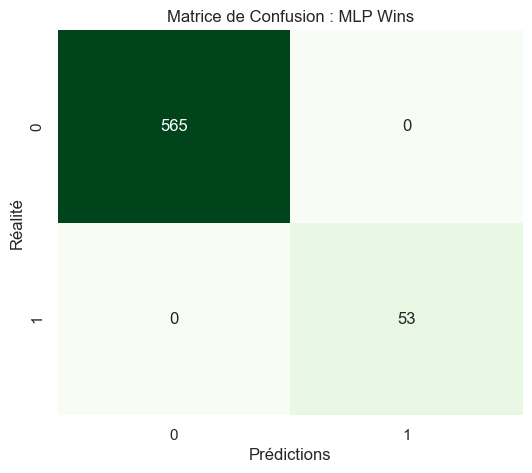

In [4]:
# Prédictions sur l'ensemble de test
y_pred_wins = mlp_wins.predict(X_test)

# Affichage des métriques
print("\n--- RÉSULTATS MLP (VICTOIRES X) ---")
print(f"Précision globale (Accuracy) : {accuracy_score(y_test_wins, y_pred_wins):.2%}")
print("\nRapport de classification :")
print(classification_report(y_test_wins, y_pred_wins))

# Matrice de confusion
plt.figure(figsize=(6, 5))
cm = confusion_matrix(y_test_wins, y_pred_wins)
sns.heatmap(cm, annot=True, fmt='d', cmap='Greens', cbar=False)
plt.title('Matrice de Confusion : MLP Wins')
plt.xlabel('Prédictions')
plt.ylabel('Réalité')
plt.show()

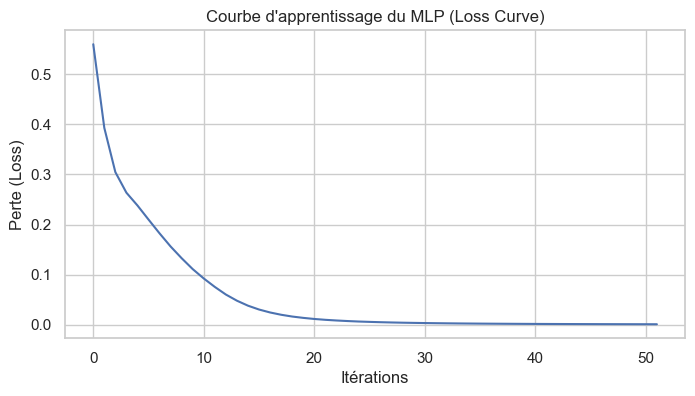

In [5]:
plt.figure(figsize=(8, 4))
plt.plot(mlp_wins.loss_curve_)
plt.title("Courbe d'apprentissage du MLP (Loss Curve)")
plt.xlabel("Itérations")
plt.ylabel("Perte (Loss)")
plt.show()

In [6]:
# Exportation pour l'interface de jeu (Mission 4)
joblib.dump(mlp_wins, '../../ressources/model_mlp_wins.pkl')
joblib.dump(mlp_draw, '../../ressources/model_mlp_draw.pkl')

print("Fichiers .pkl générés avec succès !")

Fichiers .pkl générés avec succès !
